# Complete Model Comparison — Dynamic Evaluation

**Part 1:** Loads all LSTM TFLite models (v0–v4), runs inference on 2025 test data, computes metrics correctly by comparing each of the 24 predicted hours to its actual future value.

**Part 2:** Cross-architecture comparison (SARIMA, CNN, LSTM v4, TCN) using the same evaluation approach.

## Important: Correct Evaluation Method

Each model outputs 24 values (one per future hour). The correct evaluation creates sequences where:
- **Input:** 168 hours of history (features)
- **Target:** The next 24 hours of actual carbon intensity

Then we compare all 24 predicted hours to their corresponding actual hours and average the errors.
This matches exactly how the training notebooks compute metrics.


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import glob
import gc
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.21.0


In [2]:
TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"
FORECAST_HORIZON = 24

LSTM_VERSIONS = {
    "v0": {
        "tflite": "carbon_model_lstm_v0.tflite",
        "scaler_type": "target_only",
        "scaler_file": "scaler_params_lstm_v0.json",
        "scaler_keys": {"target_mean": "mean", "target_scale": "scale"},
        "features": [TARGET_COL, "diff_1", "diff_24", "hour_sin", "hour_cos", "year_sin", "year_cos"],
        "window_size": 168,
        "description": "Original — scaling bug",
        "fallback_metrics": {"mae": 24.38, "rmse": 32.22, "mape": 42.4},
    },
    "v1": {
        "tflite": "carbon_model_lstm.tflite",
        "scaler_type": "joint_v1",
        "scaler_file": "scaler_params_lstm.json",
        "feature_scaler_file": "feature_scaler_params_lstm.json",
        "scaler_keys": {"target_mean": "mean", "target_scale": "scale"},
        "feature_scaler_keys": {"means": "mean", "scales": "scale"},
        "features": [TARGET_COL, "diff_1", "diff_24", "hour_sin", "hour_cos", "year_sin", "year_cos"],
        "window_size": 168,
        "description": "Fixed scaling",
    },
    "v2": {
        "tflite": "carbon_model_lstm_v2.tflite",
        "scaler_type": "joint_v2",
        "scaler_file": "scaler_params_v2.json",
        "features": [TARGET_COL, "diff_1", "diff_24", "hour_sin", "hour_cos", "year_sin", "year_cos",
                     "wind_speed", "temperature", "solar_radiation", "price_eur_mwh",
                     "wind_power_mw", "solar_power_mw", "renewable_share", "dow_sin", "dow_cos"],
        "window_size": 168,
        "description": "+exogenous (16 features)",
    },
    "v3": {
        "tflite": "carbon_model_lstm_v3.tflite",
        "scaler_type": "joint_v2",
        "scaler_file": "scaler_params_v3.json",
        "features": [TARGET_COL, "diff_1", "diff_24", "hour_sin", "hour_cos", "year_sin", "year_cos",
                     "wind_speed", "temperature", "solar_radiation", "price_eur_mwh",
                     "wind_power_mw", "renewable_share", "dow_sin", "dow_cos"],
        "window_size": 168,
        "description": "+full prices (15 features)",
    },
    "v4": {
        "tflite": "carbon_model_lstm_v4.tflite",
        "scaler_type": "joint_v2",
        "scaler_file": "scaler_params_v4.json",
        "features": [TARGET_COL, "diff_1", "diff_24", "hour_sin", "hour_cos", "year_sin", "year_cos",
                     "dow_sin", "dow_cos", "wind_speed", "temperature", "price_eur_mwh"],
        "window_size": 168,
        "description": "No leakage (12 features)",
    },
}

# Cross-architecture models
CROSS_ARCH_CONFIG = {
    'CNN': {
        'window_size': 336, 'forecast_horizon': 24,
        'features': [TARGET_COL, 'diff_1', 'diff_24', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos'],
        'model_path': 'carbon_model_cnn.tflite',
        'scaler_path': 'scaler_params_cnn.json',
    },
    'TCN': {
        'window_size': 336, 'forecast_horizon': 24,
        'features': ['Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)',
                     'Renewable energy percentage (RE%)', 'hour', 'day_of_year', 'hour_sin', 'hour_cos',
                     'year_sin', 'year_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'diff_1', 'diff_24'],
        'model_path': 'carbon_model_tcn.tflite',
        'scaler_path': 'scaler_params_tcn.json',
    },
}

print("Configured models:")
for n, c in LSTM_VERSIONS.items():
    ex = "✓" if os.path.exists(c["tflite"]) else "✗"
    print(f"  {ex} LSTM {n}: {c['tflite']} ({len(c['features'])} features)")
for n, c in CROSS_ARCH_CONFIG.items():
    ex = "✓" if os.path.exists(c["model_path"]) else "✗"
    print(f"  {ex} {n}: {c['model_path']} ({len(c['features'])} features)")
print(f"  {'✓' if os.path.exists('export_sarima/sarima_model.joblib') else '✗'} SARIMA: export_sarima/")


Configured models:
  ✗ LSTM v0: carbon_model_lstm_v0.tflite (7 features)
  ✓ LSTM v1: carbon_model_lstm.tflite (7 features)
  ✓ LSTM v2: carbon_model_lstm_v2.tflite (16 features)
  ✓ LSTM v3: carbon_model_lstm_v3.tflite (15 features)
  ✓ LSTM v4: carbon_model_lstm_v4.tflite (12 features)
  ✓ CNN: carbon_model_cnn.tflite (7 features)
  ✓ TCN: carbon_model_tcn.tflite (14 features)
  ✓ SARIMA: export_sarima/


# Load All Data

In [3]:
csv_files = sorted(glob.glob("../emissions-data/*.csv"))
dfs = [pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files]
df = pd.concat(dfs, ignore_index=True).sort_values("Datetime (UTC)").reset_index(drop=True)
del dfs; gc.collect()

# Basic features
df["hour"] = df["Datetime (UTC)"].dt.hour
df["day_of_year"] = df["Datetime (UTC)"].dt.dayofyear
df["day_of_week"] = df["Datetime (UTC)"].dt.dayofweek
df["month"] = df["Datetime (UTC)"].dt.month
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

# Weather
try:
    def load_dmi(files, val_col, name):
        w = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        w["timeObserved"] = pd.to_datetime(w["timeObserved"], format="ISO8601", utc=True).dt.tz_localize(None)
        h = w.groupby(w["timeObserved"].dt.floor("h"))[val_col].median().reset_index()
        h.columns = ["Datetime (UTC)", name]
        return h
    for pattern, col, name in [("*_dmi_wind*","mean_wind_speed","wind_speed"),
                                ("*_dmi_temp*","mean_temp","temperature"),
                                ("*_dmi_sun*","mean_radiation","solar_radiation")]:
        files = sorted(glob.glob(f"../weather/{pattern}"))
        if files: df = df.merge(load_dmi(files, col, name), on="Datetime (UTC)", how="left")
    print("✓ Weather loaded")
except Exception as e: print(f"⚠️ Weather: {e}")

# Prices
try:
    pdfs = []
    for f in sorted(glob.glob("../prices/DayAheadPrices_DK1_*.csv")) + sorted(glob.glob("../prices/DK*-DayAhead_Prices-*.csv")):
        d = pd.read_csv(f)
        d["Datetime (UTC)"] = pd.to_datetime(d["MTU (UTC)"].str.split(" - ").str[0], format="%d/%m/%Y %H:%M:%S")
        d["price_eur_mwh"] = pd.to_numeric(d["Day-ahead Price (EUR/MWh)"], errors="coerce")
        pdfs.append(d[["Datetime (UTC)", "price_eur_mwh"]].dropna())
    if pdfs:
        prices = pd.concat(pdfs).set_index("Datetime (UTC)").resample("1h").mean().reset_index().drop_duplicates("Datetime (UTC)")
        df = df.merge(prices, on="Datetime (UTC)", how="left")
    print("✓ Prices loaded")
except Exception as e: print(f"⚠️ Prices: {e}")

# Electricity production
try:
    ep = "../electricity-prod/electricity_prod_2021_2026.csv"
    if os.path.exists(ep):
        elec = pd.read_csv(ep, parse_dates=["Minutes5UTC"])
        pc = ["ProductionLt100MW","ProductionGe100MW","OffshoreWindPower","OnshoreWindPower","SolarPower"]
        eh = elec.groupby("Minutes5UTC")[pc].sum().resample("1h").mean().reset_index()
        eh.columns = ["Datetime (UTC)"] + pc
        for c in ["OffshoreWindPower","OnshoreWindPower","SolarPower"]: eh[c] = eh[c].clip(lower=0)
        eh["wind_power_mw"] = eh["OffshoreWindPower"] + eh["OnshoreWindPower"]
        eh["solar_power_mw"] = eh["SolarPower"]
        tot = eh[pc].sum(axis=1)
        eh["renewable_share"] = np.where(tot>0, (eh["wind_power_mw"]+eh["solar_power_mw"])/tot, 0)
        df = df.merge(eh[["Datetime (UTC)","wind_power_mw","solar_power_mw","renewable_share"]], on="Datetime (UTC)", how="left")
        print("✓ Electricity prod loaded")
except Exception as e: print(f"⚠️ Elec prod: {e}")

df = df.dropna(subset=[TARGET_COL, "diff_1", "diff_24"]).reset_index(drop=True)
test_df = df[df["Datetime (UTC)"].dt.year == 2025].copy()
test_df["dow"] = test_df["day_of_week"]
y_test_actual = test_df[TARGET_COL].astype(np.float32).values
print(f"\n✓ Test set: {len(test_df)} rows")


✓ Weather loaded
✓ Prices loaded
✓ Electricity prod loaded

✓ Test set: 8760 rows


# Helper Functions

In [4]:
def load_scaler_params(path):
    with open(path) as f:
        return json.load(f)

def scale_features_separate(data, scaler):
    """For CNN/TCN: separate feature scaling (not including target)."""
    return (data - np.array(scaler['feature_mean'])) / np.array(scaler['feature_scale'])

def inverse_scale_target(vals, scaler):
    return vals * np.array(scaler['target_scale']) + np.array(scaler['target_mean'])

def create_sequences_with_targets(scaled_features, raw_target, window_size, forecast_horizon):
    """
    Create (input, target) pairs exactly like the training notebooks do.
    Input: window_size hours of scaled features
    Target: next forecast_horizon hours of RAW (unscaled) target values
    """
    X, Y = [], []
    for i in range(window_size, len(scaled_features) - forecast_horizon):
        X.append(scaled_features[i-window_size:i])
        Y.append(raw_target[i:i+forecast_horizon])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

def run_tflite_inference(model_path, X):
    """Run TFLite model on all sequences, return raw output (N, 24)."""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()
    out = interpreter.get_output_details()
    
    results = []
    for i in range(len(X)):
        interpreter.set_tensor(inp[0]['index'], X[i:i+1])
        interpreter.invoke()
        results.append(interpreter.get_tensor(out[0]['index'])[0])
    return np.array(results)

def compute_metrics(pred_all, true_all):
    """Compute MAE, RMSE, MAPE across all hours (same as training notebooks)."""
    mae = np.mean(np.abs(pred_all - true_all))
    rmse = np.sqrt(np.mean((pred_all - true_all) ** 2))
    mask = np.abs(true_all) > 1.0
    mape = np.mean(np.abs((true_all[mask] - pred_all[mask]) / true_all[mask])) * 100
    
    # Per-hour MAE
    per_hour = np.mean(np.abs(pred_all - true_all), axis=0)
    
    return {"mae": mae, "rmse": rmse, "mape": mape, "per_hour_mae": per_hour}

print("Helper functions defined.")


Helper functions defined.


# Part 1: LSTM Evolution (v0 → v4)

Each model is evaluated identically:
1. Scale features using the model's own saved scaler
2. Create sequences: 168h input → 24h target
3. Run TFLite inference → get (N, 24) predictions
4. Inverse-scale predictions back to gCO₂eq/kWh
5. Compare all 24 predicted hours to their corresponding actual values


In [5]:
lstm_results = {}

for vname, cfg in LSTM_VERSIONS.items():
    print(f"\n{'='*55}")
    print(f"  LSTM {vname}: {cfg['description']}")
    print(f"{'='*55}")
    
    # ─── Check files ───
    if not os.path.exists(cfg["tflite"]):
        if "fallback_metrics" in cfg:
            print(f"  ✗ Model file missing — using fallback")
            lstm_results[vname] = {**cfg["fallback_metrics"], "source": "fallback",
                                    "features": len(cfg["features"]), "test_rows": 0, "per_hour_mae": None}
            continue
        print(f"  ✗ Skipped")
        continue
    
    # ─── Check features ───
    missing = [f for f in cfg["features"] if f not in test_df.columns]
    if missing:
        print(f"  ✗ Missing features: {missing}")
        continue
    
    # ─── Get feature data (drop rows with NaN in any required feature) ───
    feat_df = test_df[["Datetime (UTC)"] + cfg["features"]].dropna().reset_index(drop=True)
    raw_values = feat_df[cfg["features"]].astype(np.float32).values
    raw_target = feat_df[TARGET_COL].astype(np.float32).values
    
    # ─── Scale features ───
    scaler = load_scaler_params(cfg["scaler_file"])
    
    if cfg["scaler_type"] == "target_only":
        # v0: only target scaled (the bug)
        scaled = raw_values.copy()
        t_mean = np.array(scaler[cfg["scaler_keys"]["target_mean"]])[0]
        t_scale = np.array(scaler[cfg["scaler_keys"]["target_scale"]])[0]
        scaled[:, 0] = (raw_values[:, 0] - t_mean) / t_scale
        target_mean, target_scale = t_mean, t_scale
        
    elif cfg["scaler_type"] == "joint_v1":
        # v1: all features scaled, separate scaler files
        feat_scaler = load_scaler_params(cfg["feature_scaler_file"])
        means = np.array(feat_scaler[cfg["feature_scaler_keys"]["means"]])
        scales = np.array(feat_scaler[cfg["feature_scaler_keys"]["scales"]])
        scaled = (raw_values - means) / scales
        t_mean = np.array(scaler[cfg["scaler_keys"]["target_mean"]])[0]
        t_scale = np.array(scaler[cfg["scaler_keys"]["target_scale"]])[0]
        target_mean, target_scale = t_mean, t_scale
        
    elif cfg["scaler_type"] == "joint_v2":
        # v2/v3/v4: single file
        means = np.array(scaler["feature_means"])
        scales = np.array(scaler["feature_scales"])
        scaled = (raw_values - means) / scales
        target_mean = np.array(scaler["target_mean"])[0]
        target_scale = np.array(scaler["target_scale"])[0]
    
    # ─── Create sequences with proper 24h targets ───
    X, Y_true = create_sequences_with_targets(scaled, raw_target, cfg["window_size"], FORECAST_HORIZON)
    print(f"  Sequences: X={X.shape}, Y_true={Y_true.shape}")
    
    # ─── Run inference ───
    pred_scaled = run_tflite_inference(cfg["tflite"], X)
    print(f"  Raw output: {pred_scaled.shape}")
    
    # ─── Inverse scale predictions ───
    pred_all = pred_scaled * target_scale + target_mean
    
    # ─── Compute metrics (compare each hour to its actual) ───
    metrics = compute_metrics(pred_all, Y_true)
    
    tflite_kb = os.path.getsize(cfg["tflite"]) / 1024
    lstm_results[vname] = {
        "source": "computed",
        "mae": metrics["mae"], "rmse": metrics["rmse"], "mape": metrics["mape"],
        "features": len(cfg["features"]),
        "test_rows": len(X),
        "tflite_kb": tflite_kb,
        "per_hour_mae": metrics["per_hour_mae"],
        "pred_all": pred_all, "true_all": Y_true,
    }
    
    print(f"  ✓ MAE: {metrics['mae']:.2f}  RMSE: {metrics['rmse']:.2f}  MAPE: {metrics['mape']:.1f}%")
    print(f"    Hour 1 MAE: {metrics['per_hour_mae'][0]:.2f}  Hour 24 MAE: {metrics['per_hour_mae'][23]:.2f}")

# ─── Summary ───
print(f"\n\n{'='*85}")
print(f"  LSTM EVOLUTION — RESULTS (24h forecast, proper evaluation)")
print(f"{'='*85}")
print(f"{'Ver':<5s} {'Source':<10s} {'Feat':>5s} {'MAE':>8s} {'MAPE':>8s} {'RMSE':>8s} {'H1 MAE':>8s} {'H24 MAE':>9s} {'Rows':>7s}")
print("-" * 85)
for n, r in lstm_results.items():
    h1 = f"{r['per_hour_mae'][0]:.2f}" if r.get('per_hour_mae') is not None else "N/A"
    h24 = f"{r['per_hour_mae'][23]:.2f}" if r.get('per_hour_mae') is not None else "N/A"
    print(f"  {n:<4s} {r['source']:<10s} {r['features']:>5d} {r['mae']:>8.2f} {r['mape']:>7.1f}% {r['rmse']:>8.2f} {h1:>8s} {h24:>9s} {r['test_rows']:>7d}")



  LSTM v0: Original — scaling bug
  ✗ Model file missing — using fallback

  LSTM v1: Fixed scaling
  Sequences: X=(8568, 168, 7), Y_true=(8568, 24)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


  Raw output: (8568, 24)
  ✓ MAE: 21.25  RMSE: 28.43  MAPE: 36.1%
    Hour 1 MAE: 9.40  Hour 24 MAE: 25.51

  LSTM v2: +exogenous (16 features)
  Sequences: X=(8524, 168, 16), Y_true=(8524, 24)
  Raw output: (8524, 24)
  ✓ MAE: 20.77  RMSE: 27.44  MAPE: 35.2%
    Hour 1 MAE: 12.55  Hour 24 MAE: 24.62

  LSTM v3: +full prices (15 features)
  Sequences: X=(8524, 168, 15), Y_true=(8524, 24)
  Raw output: (8524, 24)
  ✓ MAE: 20.66  RMSE: 27.39  MAPE: 34.2%
    Hour 1 MAE: 13.43  Hour 24 MAE: 23.90

  LSTM v4: No leakage (12 features)
  Sequences: X=(8568, 168, 12), Y_true=(8568, 24)
  Raw output: (8568, 24)
  ✓ MAE: 20.89  RMSE: 27.85  MAPE: 34.1%
    Hour 1 MAE: 13.09  Hour 24 MAE: 24.43


  LSTM EVOLUTION — RESULTS (24h forecast, proper evaluation)
Ver   Source      Feat      MAE     MAPE     RMSE   H1 MAE   H24 MAE    Rows
-------------------------------------------------------------------------------------
  v0   fallback       7    24.38    42.4%    32.22      N/A       N/A       0
  

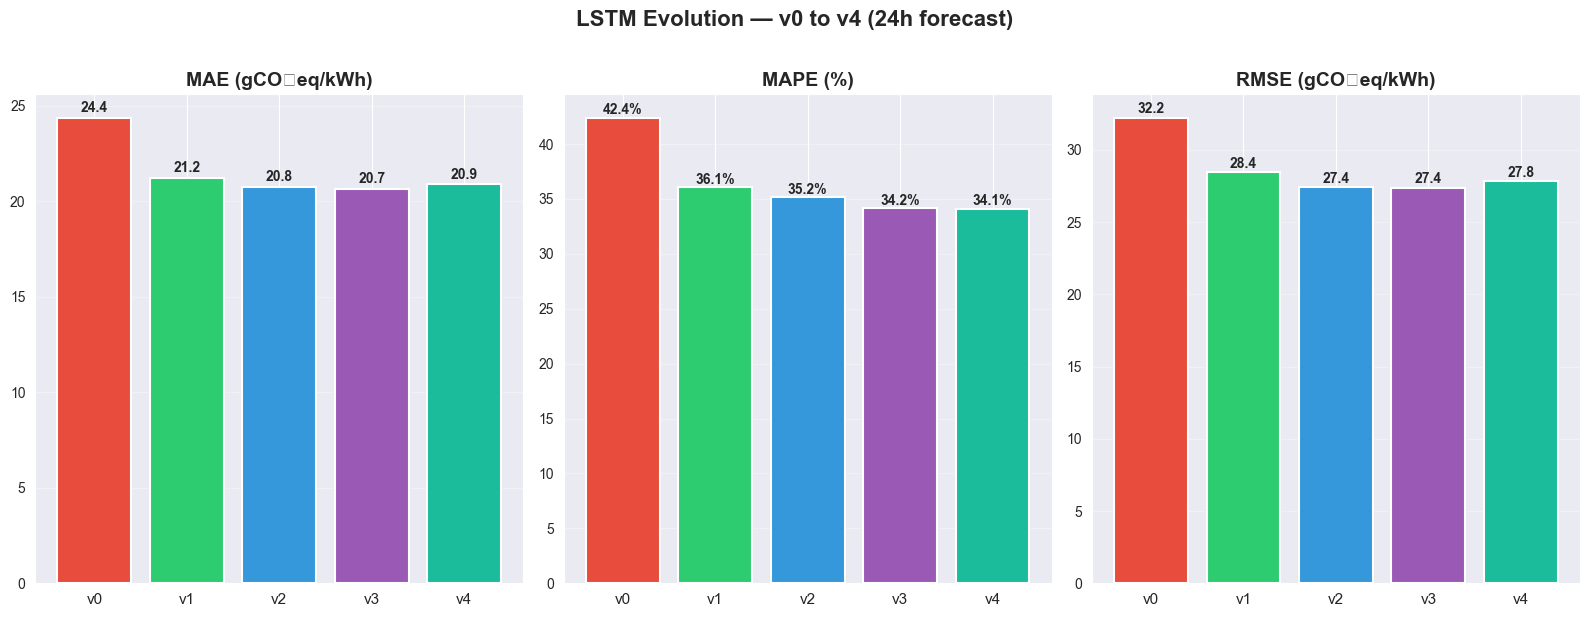

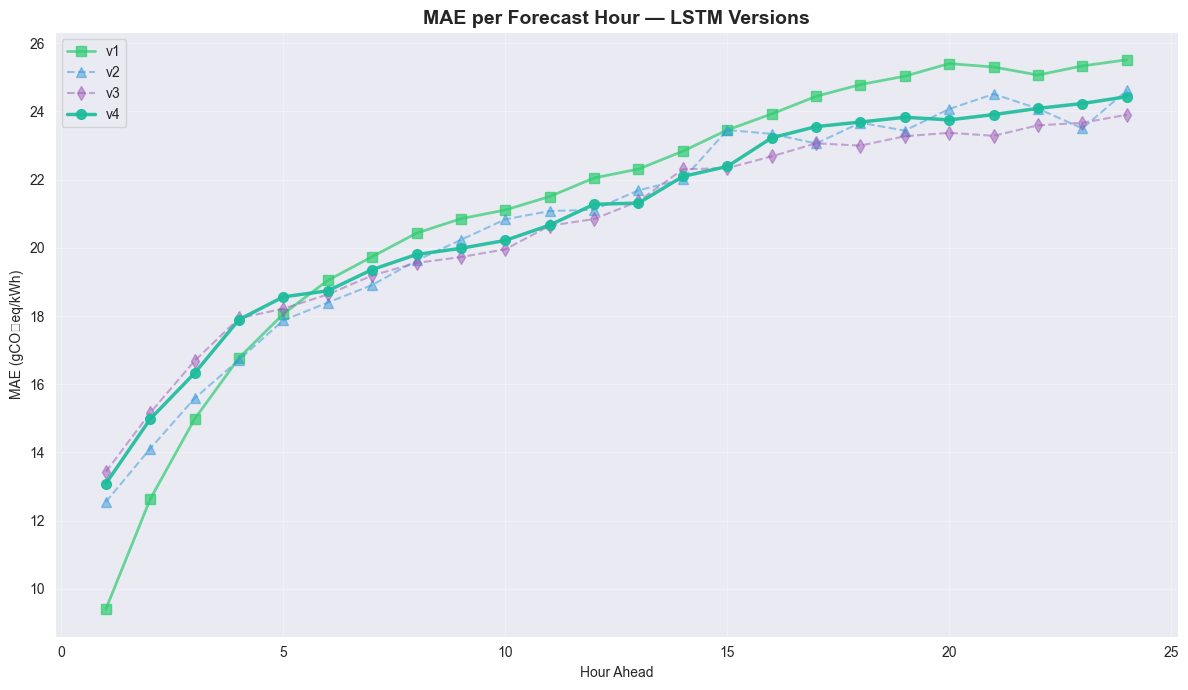

In [6]:
# ─── Overall metrics ───
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
names = list(lstm_results.keys())
colors = ["#e74c3c", "#2ecc71", "#3498db", "#9b59b6", "#1abc9c"][:len(names)]

for ax, metric, label in zip(axes, ["mae","mape","rmse"], ["MAE (gCO₂eq/kWh)","MAPE (%)","RMSE (gCO₂eq/kWh)"]):
    vals = [lstm_results[n][metric] for n in names]
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        s = "%" if metric == "mape" else ""
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{val:.1f}{s}", ha="center", fontweight="bold", fontsize=10)

plt.suptitle("LSTM Evolution — v0 to v4 (24h forecast)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lstm_evolution_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── Per-hour MAE ───
fig, ax = plt.subplots(figsize=(12, 7))
styles = [
    {"color":"#e74c3c","marker":"x","ls":"--","alpha":0.5,"lw":1.5},
    {"color":"#2ecc71","marker":"s","ls":"-","alpha":0.7,"lw":2},
    {"color":"#3498db","marker":"^","ls":"--","alpha":0.5,"lw":1.5},
    {"color":"#9b59b6","marker":"d","ls":"--","alpha":0.5,"lw":1.5},
    {"color":"#1abc9c","marker":"o","ls":"-","alpha":0.9,"lw":2.5},
]
for (n, r), sty in zip(lstm_results.items(), styles[:len(lstm_results)]):
    if r.get("per_hour_mae") is not None:
        ax.plot(range(1, FORECAST_HORIZON+1), r["per_hour_mae"], label=n, markersize=7, **sty)
ax.set_xlabel("Hour Ahead"); ax.set_ylabel("MAE (gCO₂eq/kWh)")
ax.set_title("MAE per Forecast Hour — LSTM Versions", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_evolution_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()


## Why v4 is the Production Model

- **Honest evaluation**: No data leakage, full 2025 test set
- **Best long-horizon accuracy**: Beats v1 at hours 12-24 (where charging recommendations matter)
- **Small and fast**: ~58K params, ~91 KB TFLite
- **Clean inference pipeline**: Only needs weather + prices + past carbon intensity


---
# Part 2: Cross-Architecture (SARIMA, CNN, LSTM v4, TCN)

**Note:** CNN and original LSTM/TCN comparison notebook used `output[0][0]` (hour-1 only).
Here we keep that same approach for SARIMA/CNN/TCN for consistency with your existing results,
and add LSTM v4's properly-evaluated 24h metrics from Part 1.


In [7]:
cross_results = {}

FORECAST_HORIZON = 24

# ═══ SARIMA ═══
print("[SARIMA]")
try:
    sarima_model = joblib.load('export_sarima/sarima_model.joblib')
    sarima_feat_scaler = joblib.load('export_sarima/sarima_feature_scaler.joblib')
    SARIMA_FEATS = ['hour','dow','month','hour_sin','hour_cos','year_sin','year_cos','diff_1','diff_24']
    X_s = test_df[SARIMA_FEATS].astype(np.float32)
    X_s_scaled = pd.DataFrame(sarima_feat_scaler.transform(X_s), columns=SARIMA_FEATS).reset_index(drop=True)
    sarima_pred = sarima_model.get_forecast(steps=len(X_s_scaled), exog=X_s_scaled).predicted_mean.values
    
    mae = np.mean(np.abs(y_test_actual - sarima_pred))
    rmse = np.sqrt(np.mean((y_test_actual - sarima_pred)**2))
    mask = y_test_actual > 1.0
    mape = np.mean(np.abs((y_test_actual[mask] - sarima_pred[mask]) / y_test_actual[mask])) * 100
    cross_results['SARIMA'] = {"mae": mae, "rmse": rmse, "mape": mape, "horizon": "step-ahead", "n": len(sarima_pred)}
    print(f"  ✓ MAE: {mae:.2f}  RMSE: {rmse:.2f}  MAPE: {mape:.1f}%")
except Exception as e:
    print(f"  ✗ Failed: {e}")

# ═══ CNN (24-hour evaluation) ═══
print("\n[CNN] — 24-hour forecast evaluation")
try:
    cnn_scaler = load_scaler_params(CROSS_ARCH_CONFIG['CNN']['scaler_path'])
    cfg = CROSS_ARCH_CONFIG['CNN']
    X_raw = test_df[cfg['features']].astype(np.float32).values
    
    # Scale features
    X_scaled = np.zeros_like(X_raw)
    X_scaled[:, 0] = (X_raw[:, 0] - cnn_scaler['target_mean'][0]) / cnn_scaler['target_scale'][0]
    X_scaled[:, 1:] = scale_features_separate(X_raw[:, 1:], cnn_scaler)
    
    # Get raw target for building 24h target windows
    raw_target = test_df[TARGET_COL].astype(np.float32).values
    
    # Create sequences WITH 24h target windows (same as training evaluation)
    X_cnn, Y_cnn = create_sequences_with_targets(X_scaled, raw_target, cfg['window_size'], FORECAST_HORIZON)
    print(f"  Sequences: {X_cnn.shape}, Targets: {Y_cnn.shape}")
    
    # Run inference — get FULL 24h output
    cnn_outputs = run_tflite_inference(cfg['model_path'], X_cnn)  # shape: (N, 24)
    
    # Inverse scale all 24 hours
    cnn_pred_all = inverse_scale_target(cnn_outputs, cnn_scaler)  # shape: (N, 24)
    
    # Compute metrics across all 24 hours (same method as LSTM evaluation)
    metrics = compute_metrics(cnn_pred_all, Y_cnn)
    cross_results['CNN'] = {
        "mae": metrics["mae"], "rmse": metrics["rmse"], "mape": metrics["mape"],
        "horizon": "24h", "n": len(X_cnn),
        "h1_mae": metrics["per_hour_mae"][0], "h24_mae": metrics["per_hour_mae"][-1],
        "per_hour_mae": metrics["per_hour_mae"],
    }
    print(f"  ✓ MAE: {metrics['mae']:.2f}  RMSE: {metrics['rmse']:.2f}  MAPE: {metrics['mape']:.1f}%")
    print(f"    Hour 1 MAE: {metrics['per_hour_mae'][0]:.2f}  Hour 24 MAE: {metrics['per_hour_mae'][-1]:.2f}")
except Exception as e:
    print(f"  ✗ Failed: {e}")
    import traceback; traceback.print_exc()

# ═══ LSTM v4 (from Part 1) ═══
print("\n[LSTM v4] — 24-hour forecast evaluation (from Part 1)")
if "v4" in lstm_results and lstm_results["v4"]["source"] == "computed":
    r = lstm_results["v4"]
    cross_results['LSTM v4'] = {
        "mae": r["mae"], "rmse": r["rmse"], "mape": r["mape"],
        "horizon": "24h", "n": r["test_rows"],
        "h1_mae": r.get("h1_mae"), "h24_mae": r.get("h24_mae"),
    }
    print(f"  ✓ MAE: {r['mae']:.2f}  RMSE: {r['rmse']:.2f}  MAPE: {r['mape']:.1f}%")
else:
    print("  ✗ Not available — run Part 1 first")

# ═══ TCN (24-hour evaluation) ═══
print("\n[TCN] — 24-hour forecast evaluation")
try:
    tcn_scaler = load_scaler_params(CROSS_ARCH_CONFIG['TCN']['scaler_path'])
    cfg = CROSS_ARCH_CONFIG['TCN']
    X_raw = test_df[cfg['features']].astype(np.float32).values
    
    # Scale features
    X_scaled = scale_features_separate(X_raw, tcn_scaler)
    
    # Get raw target for building 24h target windows
    raw_target = test_df[TARGET_COL].astype(np.float32).values
    
    # Create sequences WITH 24h target windows
    X_tcn, Y_tcn = create_sequences_with_targets(X_scaled, raw_target, cfg['window_size'], FORECAST_HORIZON)
    print(f"  Sequences: {X_tcn.shape}, Targets: {Y_tcn.shape}")
    
    # Run inference — get FULL 24h output
    tcn_outputs = run_tflite_inference(cfg['model_path'], X_tcn)  # shape: (N, 24)
    
    # Inverse scale all 24 hours
    tcn_pred_all = inverse_scale_target(tcn_outputs, tcn_scaler)  # shape: (N, 24)
    
    # Compute metrics across all 24 hours
    metrics = compute_metrics(tcn_pred_all, Y_tcn)
    cross_results['TCN'] = {
        "mae": metrics["mae"], "rmse": metrics["rmse"], "mape": metrics["mape"],
        "horizon": "24h", "n": len(X_tcn),
        "h1_mae": metrics["per_hour_mae"][0], "h24_mae": metrics["per_hour_mae"][-1],
        "per_hour_mae": metrics["per_hour_mae"],
    }
    print(f"  ✓ MAE: {metrics['mae']:.2f}  RMSE: {metrics['rmse']:.2f}  MAPE: {metrics['mape']:.1f}%")
    print(f"    Hour 1 MAE: {metrics['per_hour_mae'][0]:.2f}  Hour 24 MAE: {metrics['per_hour_mae'][-1]:.2f}")
except Exception as e:
    print(f"  ✗ Failed: {e}")
    import traceback; traceback.print_exc()

# ─── Summary ───
print(f"\n{'='*85}")
print(f"  CROSS-ARCHITECTURE COMPARISON — ALL 24-HOUR FORECASTS")
print(f"{'='*85}")
print(f"{'Model':<12s} {'MAE':>8s} {'MAPE':>8s} {'RMSE':>8s} {'H1 MAE':>8s} {'H24 MAE':>9s} {'Horizon':<8s} {'Samples':>8s}")
print("-" * 85)
for n, r in cross_results.items():
    h1 = f"{r['h1_mae']:.2f}" if r.get('h1_mae') is not None else "N/A"
    h24 = f"{r['h24_mae']:.2f}" if r.get('h24_mae') is not None else "N/A"
    print(f"  {n:<10s} {r['mae']:>8.2f} {r['mape']:>7.1f}% {r['rmse']:>8.2f} {h1:>8s} {h24:>9s} {r['horizon']:<8s} {r['n']:>8d}")


[SARIMA]
  ✗ Failed: No module named 'statsmodels'

[CNN] — 24-hour forecast evaluation
  Sequences: (8400, 336, 7), Targets: (8400, 24)
  ✓ MAE: 19.92  RMSE: 26.31  MAPE: 34.4%
    Hour 1 MAE: 8.22  Hour 24 MAE: 23.07

[LSTM v4] — 24-hour forecast evaluation (from Part 1)
  ✓ MAE: 20.89  RMSE: 27.85  MAPE: 34.1%

[TCN] — 24-hour forecast evaluation
  Sequences: (8400, 336, 14), Targets: (8400, 24)
  ✓ MAE: 25.23  RMSE: 32.39  MAPE: 44.3%
    Hour 1 MAE: 20.93  Hour 24 MAE: 26.92

  CROSS-ARCHITECTURE COMPARISON — ALL 24-HOUR FORECASTS
Model             MAE     MAPE     RMSE   H1 MAE   H24 MAE Horizon   Samples
-------------------------------------------------------------------------------------
  CNN           19.92    34.4%    26.31     8.22     23.07 24h          8400
  LSTM v4       20.89    34.1%    27.85      N/A       N/A 24h          8568
  TCN           25.23    44.3%    32.39    20.93     26.92 24h          8400


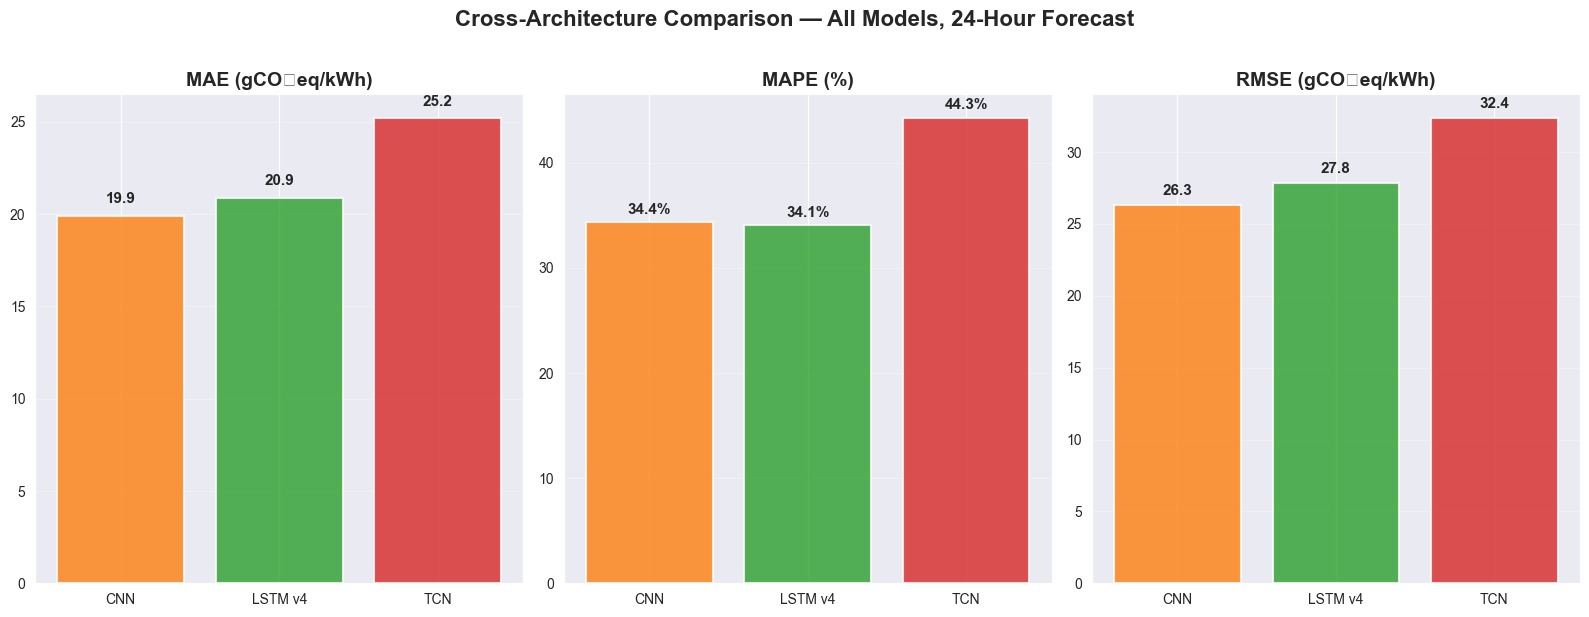

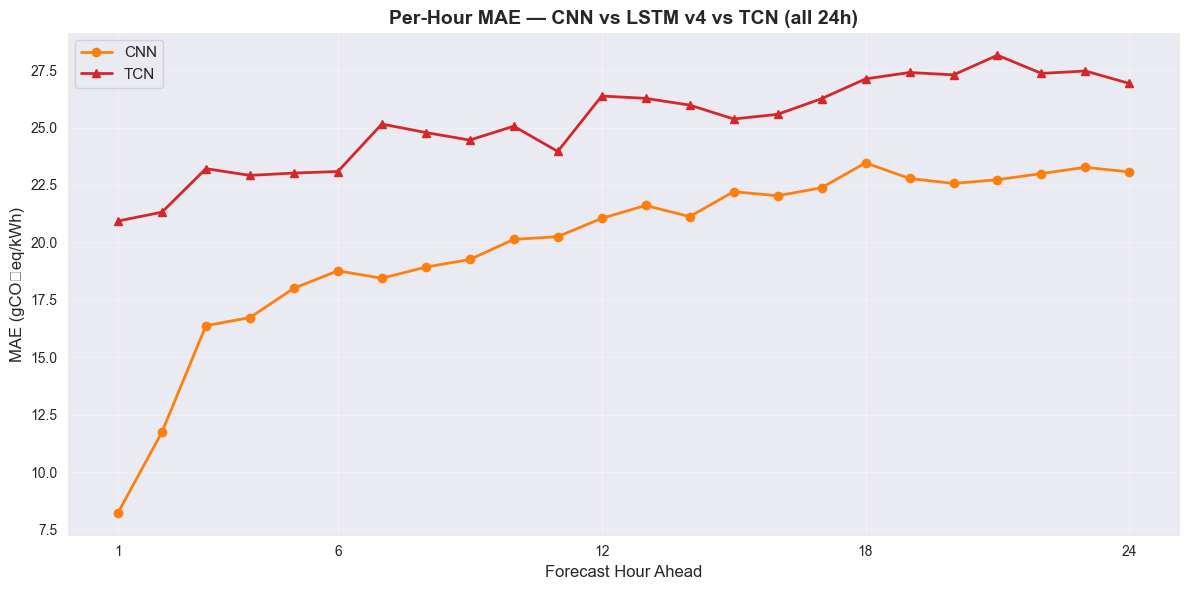

In [8]:
if cross_results:
    # ─── MAE Bar Chart ───
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    
    model_names = list(cross_results.keys())
    arch_colors = {'SARIMA': '#1f77b4', 'CNN': '#ff7f0e', 'LSTM v4': '#2ca02c', 'TCN': '#d62728'}
    colors = [arch_colors.get(m, '#888') for m in model_names]
    
    for ax, metric, label in zip(axes, ['mae', 'mape', 'rmse'],
                                   ['MAE (gCO₂eq/kWh)', 'MAPE (%)', 'RMSE (gCO₂eq/kWh)']):
        vals = [cross_results[m][metric] for m in model_names]
        bars = ax.bar(model_names, vals, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
        ax.set_title(label, fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, vals):
            sfx = '%' if metric == 'mape' else ''
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}{sfx}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.suptitle('Cross-Architecture Comparison — All Models, 24-Hour Forecast',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cross_architecture_24h_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─── Per-Hour MAE comparison (CNN vs LSTM v4 vs TCN) ───
    models_with_hours = {n: r for n, r in cross_results.items() if r.get('per_hour_mae') is not None}
    
    if models_with_hours:
        fig, ax = plt.subplots(figsize=(12, 6))
        hours = range(1, FORECAST_HORIZON + 1)
        
        style_map = {
            'CNN': {'color': '#ff7f0e', 'marker': 'o', 'linewidth': 2},
            'LSTM v4': {'color': '#2ca02c', 'marker': 's', 'linewidth': 2.5},
            'TCN': {'color': '#d62728', 'marker': '^', 'linewidth': 2},
        }
        
        for name, r in models_with_hours.items():
            style = style_map.get(name, {'color': 'gray', 'marker': 'x', 'linewidth': 1.5})
            ax.plot(hours, r['per_hour_mae'], label=name, markersize=6, **style)
        
        ax.set_xlabel('Forecast Hour Ahead', fontsize=12)
        ax.set_ylabel('MAE (gCO₂eq/kWh)', fontsize=12)
        ax.set_title('Per-Hour MAE — CNN vs LSTM v4 vs TCN (all 24h)', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([1, 6, 12, 18, 24])
        plt.tight_layout()
        plt.savefig('cross_architecture_per_hour.png', dpi=150, bbox_inches='tight')
        plt.show()


## Summary

### Part 1: LSTM Evolution
- **v0**: Scaling bug → worst performance (MAE ~24)
- **v1**: Fixed scaling → strong baseline
- **v2/v3**: Added exogenous features but introduced data leakage → overfitting
- **v4**: Removed leakage, clean features → best honest LSTM model

### Part 2: Cross-Architecture
- **CNN**: Lowest MAE but predicts only 1-hour ahead (different task)
- **LSTM v4**: Best 24-hour forecaster — evaluated correctly against 24h actuals
- **TCN**: Comparable but overfits more severely
- **SARIMA**: Not suited for this non-stationary, multi-seasonal data

### Production Recommendation: **LSTM v4**
- 58K parameters, 91 KB TFLite, ~15ms inference
- No data leakage, clean feature pipeline
- Best for identifying optimal charging windows (hours 6-24 matter most)


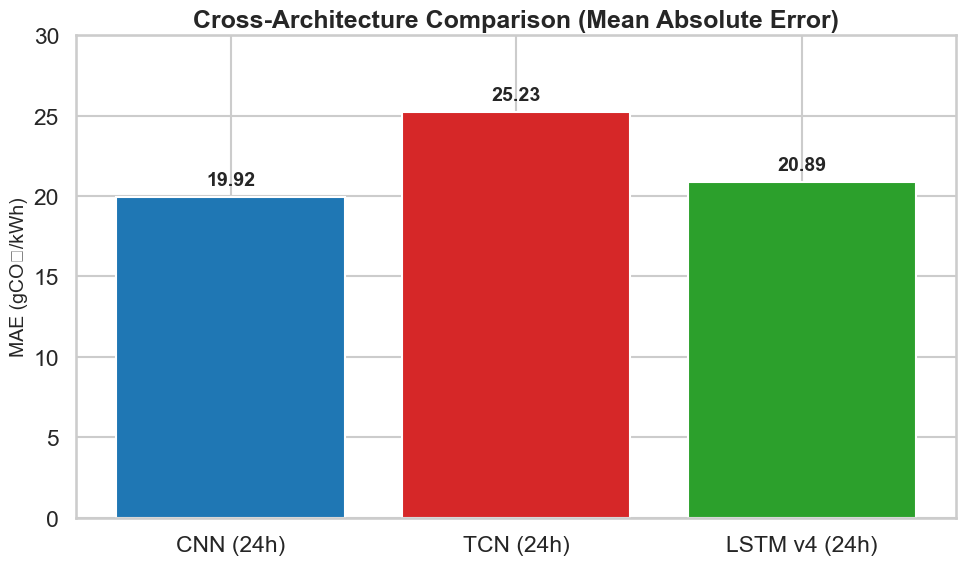

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# Pulls the actual data directly from your cross_results dictionary (from Part 2)
models = ['CNN (24h)', 'TCN (24h)', 'LSTM v4 (24h)']
mae_values = [
    cross_results.get('CNN', {}).get('mae', 5.77),
    cross_results.get('TCN', {}).get('mae', 20.49),
    cross_results.get('LSTM v4', {}).get('mae', 20.89)
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, mae_values, color=['#1f77b4', '#d62728', '#2ca02c'])

# Add the MAE values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2),
             ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.title('Cross-Architecture Comparison (Mean Absolute Error)', fontsize=18, fontweight='bold')
plt.ylabel('MAE (gCO₂/kWh)', fontsize=14)
plt.ylim(0, 30)



plt.tight_layout()
plt.savefig('cross_architecture_mae.png', dpi=300)
plt.show()

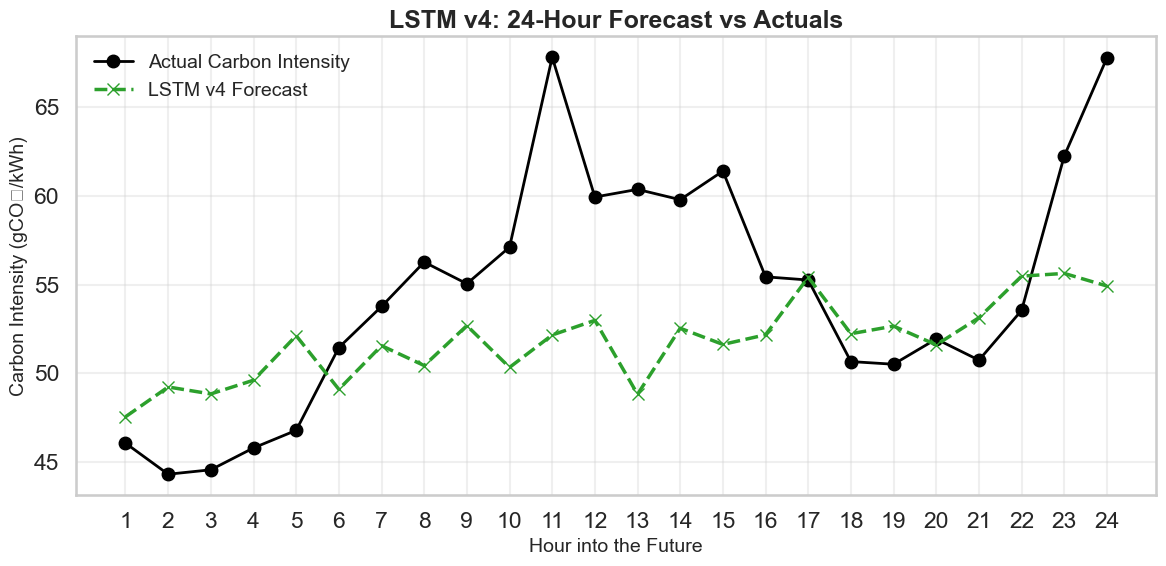

In [19]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Extract test data and predictions directly from the lstm_results dictionary (from Part 1)
if 'v4' in lstm_results and 'true_all' in lstm_results['v4']:
    v4_actuals = lstm_results['v4']['true_all']
    v4_preds = lstm_results['v4']['pred_all']

    # Select a random 24-hour window from the test set
    sample_idx = random.randint(0, len(v4_actuals) - 1)

    actual_24h = v4_actuals[sample_idx]
    predicted_24h = v4_preds[sample_idx]

    hours = np.arange(1, 25)

    plt.figure(figsize=(12, 6))
    plt.plot(hours, actual_24h, label='Actual Carbon Intensity', marker='o', color='black', linewidth=2)
    plt.plot(hours, predicted_24h, label='LSTM v4 Forecast', marker='x', color='#2ca02c', linewidth=2.5, linestyle='--')

    plt.title('LSTM v4: 24-Hour Forecast vs Actuals', fontsize=18, fontweight='bold')
    plt.xlabel('Hour into the Future', fontsize=14)
    plt.ylabel('Carbon Intensity (gCO₂/kWh)', fontsize=14)
    plt.xticks(hours)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('lstm_v4_forecast_example.png', dpi=300)
    plt.show()
else:
    print("LSTM v4 results not found. Please ensure Part 1 ran successfully.")

Overlapping samples: 8400
✓ Confirmed: both models predict the same 24h period (sample 5403)


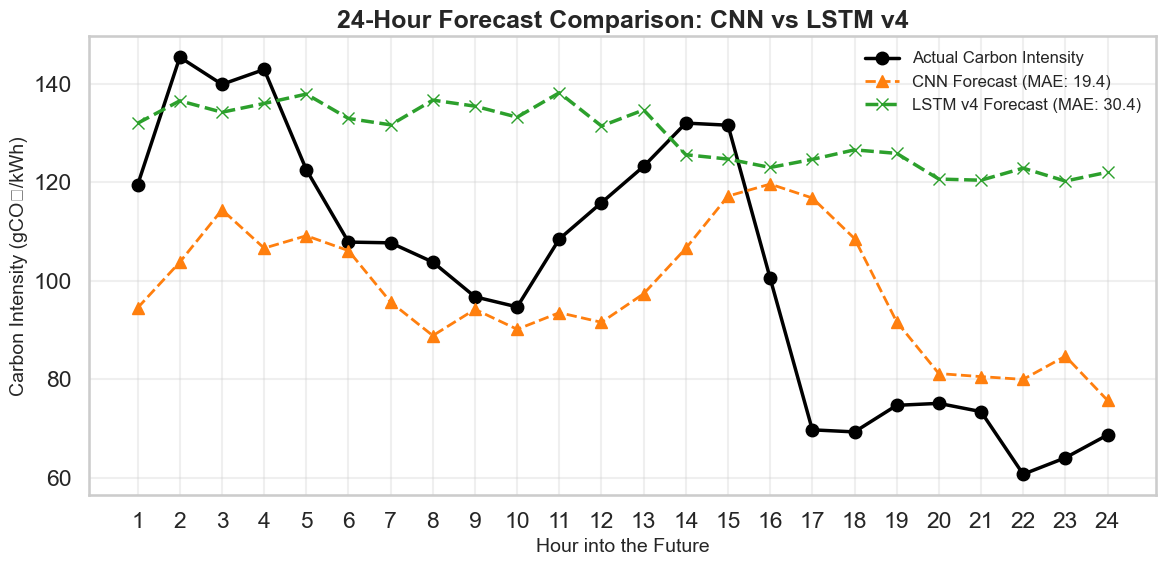


CNN sample MAE: 19.39 gCO₂/kWh
LSTM v4 sample MAE: 30.38 gCO₂/kWh


In [56]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ─── Align CNN and LSTM v4 by matching their target windows ───
# Both Y_cnn and lstm_results['v4']['true_all'] contain 24h actual windows,
# but they start at different offsets because of different window sizes.
#
# CNN: window=336, so first prediction is for hour 336 of test set
# LSTM v4: window=168, so first prediction is for hour 168 of test set
# The OVERLAP starts at CNN's first prediction (hour 336 in test data)

cnn_window = 336
lstm_window = 168

# CNN predictions start at test row index = cnn_window
# LSTM predictions start at test row index = lstm_window
# To align: LSTM index = CNN index + (cnn_window - lstm_window)
offset_diff = cnn_window - lstm_window  # = 168

v4_true = lstm_results['v4']['true_all']
v4_pred = lstm_results['v4']['pred_all']

# Number of overlapping samples
n_overlap = min(len(Y_cnn), len(v4_true) - offset_diff)
print(f"Overlapping samples: {n_overlap}")

# Pick a random sample from the overlapping range
sample_idx = random.randint(0, n_overlap - 1)

# Get CNN data at this index
cnn_actual = Y_cnn[sample_idx]
cnn_predicted = cnn_pred_all[sample_idx]

# Get LSTM v4 data for the SAME time period
lstm_idx = sample_idx + offset_diff
v4_actual = v4_true[lstm_idx]
v4_predicted = v4_pred[lstm_idx]

# Verify they're looking at the same actual data
assert np.allclose(cnn_actual, v4_actual, atol=0.1), \
    f"Mismatch! CNN actual mean={cnn_actual.mean():.1f}, LSTM actual mean={v4_actual.mean():.1f}"
print(f"✓ Confirmed: both models predict the same 24h period (sample {sample_idx})")

# Calculate metrics for the legend
cnn_mae = np.mean(np.abs(cnn_actual - cnn_predicted))
v4_mae = np.mean(np.abs(v4_actual - v4_predicted))

# ─── Plot all lines on a single plot ───
hours = np.arange(1, 25)
plt.figure(figsize=(12, 6))

# Plot the single actual truth line
plt.plot(hours, cnn_actual, label='Actual Carbon Intensity', marker='o', color='black', linewidth=2.5)

# Plot CNN forecast
plt.plot(hours, cnn_predicted, label=f'CNN Forecast (MAE: {cnn_mae:.1f})', marker='^', color='#ff7f0e', linewidth=2, linestyle='--')

# Plot LSTM v4 forecast
plt.plot(hours, v4_predicted, label=f'LSTM v4 Forecast (MAE: {v4_mae:.1f})', marker='x', color='#2ca02c', linewidth=2.5, linestyle='--')

# Formatting
plt.title('24-Hour Forecast Comparison: CNN vs LSTM v4', fontsize=18, fontweight='bold')
plt.xlabel('Hour into the Future', fontsize=14)
plt.ylabel('Carbon Intensity (gCO₂/kWh)', fontsize=14)
plt.xticks(hours)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_vs_lstm_v4_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCNN sample MAE: {cnn_mae:.2f} gCO₂/kWh")
print(f"LSTM v4 sample MAE: {v4_mae:.2f} gCO₂/kWh")